<a href="https://colab.research.google.com/github/arjanafridi123/Hotel-Booking-Analysis-EDA-Capstone-Project/blob/main/Hotel_Booking_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Hotel Booking Analysis**

# **Objective**

The objective of this project is to perform Exploratory Data Analysis (EDA) on hotel booking data from both City Hotels and Resort Hotels. The analysis focuses on understanding booking patterns, cancellation behavior, pricing trends (ADR), customer segments, market segments, and geographical demand.

By identifying key factors that influence hotel bookings and cancellations, this project aims to generate actionable business insights that can support revenue management, marketing strategies, and operational decision-making.

# **Problem Statement**

1. How do booking cancellation patterns differ between City Hotel and Resort Hotel?

2. How do booking patterns vary across months for City Hotels and Resort Hotels?

3. How are successful hotel bookings distributed across different countries worldwide?

4. Which market segments contribute the most bookings for each hotel type?

5. How does the Average Daily Rate (ADR) vary across months for City Hotel and Resort Hotel?

6. Which deposit policies are associated with the highest booking cancellation rates?

7. Which customer types have the highest cancellation rates?

# **Importing Libraries**

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import plotly.express as px

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Loading Dataset**

In [46]:
df = pd.read_csv('/content/Hotel Bookings.csv')

In [47]:
# Check first 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [48]:
# Check dataset shape
df.shape

(119390, 32)

In [49]:
# Check dataset columns
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [50]:
# Check dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [51]:
# Create dataset copy
hotel_df = df.copy()

# **Duplicate Check**

In [52]:
# Count duplicate records
duplicate_count = hotel_df.duplicated().sum()

# Calculate duplicate percentage
duplicate_percentage = duplicate_count / len(hotel_df) * 100


print(f"Duplicate Records: {duplicate_count}")
print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

Duplicate Records: 31994
Duplicate Percentage: 26.80%


In [53]:
# View duplicate records
dup_rows = hotel_df[hotel_df.duplicated(keep=False)]

In [54]:
dup_rows.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07


In [55]:
# Remove duplicates
hotel_df = hotel_df.drop_duplicates()

# **Checking Null Values in Dataset**

In [56]:
# Checking null values
hotel_df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [57]:
# Fill missing values
hotel_df["children"] = hotel_df["children"].fillna(0)
hotel_df["country"] = hotel_df["country"].fillna("Unknown")

# Drop non-essential columns
hotel_df = hotel_df.drop(columns=['company', 'agent'])

In [58]:
# Verify missing values
hotel_df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [59]:
# Dataset shape after cleaning
hotel_df.shape

(87396, 30)

## **Get summary statistics of the dataset**

In [60]:
hotel_df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138633,0.010824,0.039075,0.030413,0.183990,0.271603,0.749565,106.337246,0.084226,0.698567
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455871,0.113597,0.193775,0.369145,1.731894,0.727245,10.015731,55.013953,0.281533,0.831946
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


In [61]:
# Remove bookings where the total number of guests is zero
hotel_df[(hotel_df["adults"] == 0) & (hotel_df["children"] == 0) & (hotel_df["babies"] == 0)].shape

(166, 30)

In [62]:
# Remove invalid bookings with no guests
hotel_df = hotel_df[~((hotel_df["adults"] == 0) & (hotel_df["children"] == 0) & (hotel_df["babies"] == 0))]

Bookings with zero adults, zero children, and zero babies were removed because they do not represent valid hotel reservations.


In [63]:
# Remove undefined market segment
hotel_df = hotel_df[hotel_df['market_segment'] != 'Undefined']

Records with an undefined market segment were removed to ensure consistent and meaningful analysis.

In [64]:
hotel_df.shape

(87228, 30)

After removing duplicate records, invalid bookings, and undefined market segments, the dataset contains **87,228 rows** and **30 columns**.

# **Data Analysis & Visialization**

# **How do booking cancellation patterns differ between City Hotel and Resort Hotel?**

In [65]:
hotel_df['hotel'].value_counts()

,count
hotel,
City Hotel,53272
Resort Hotel,33956


In [66]:
hotel_df['is_canceled'].value_counts()

,count
is_canceled,
0,63221
1,24007


In [67]:
hotel_df[hotel_df['is_canceled']==0]['hotel'].value_counts()

,count
hotel,
City Hotel,37239
Resort Hotel,25982


In [68]:
hotel_df[hotel_df['is_canceled']==1]['hotel'].value_counts()

,count
hotel,
City Hotel,16033
Resort Hotel,7974


In [69]:
hotel_cancel_status = pd.crosstab(hotel_df['hotel'], hotel_df['is_canceled'])
hotel_cancel_status.columns = ['not_cancelled', 'cancelled']
hotel_cancel_status = hotel_cancel_status.reset_index()

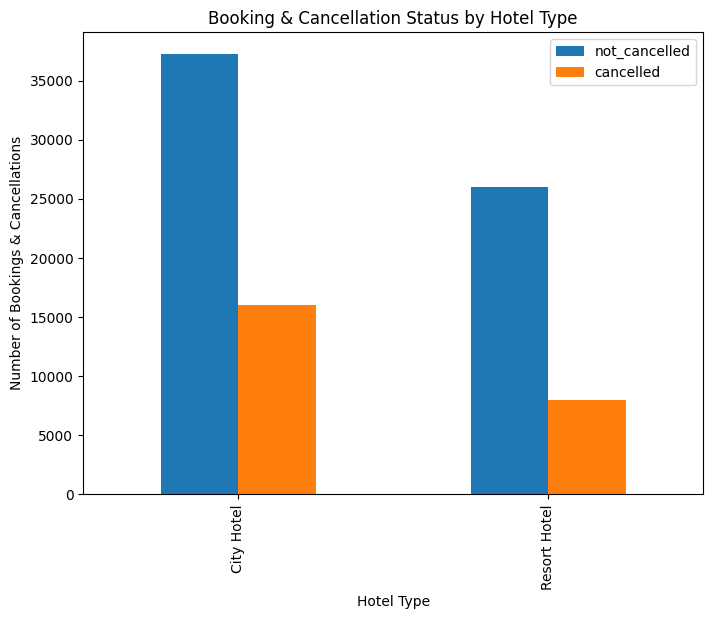

In [70]:
hotel_cancel_status.plot(x='hotel', y=['not_cancelled', 'cancelled'], kind='bar', figsize=(8,6))

plt.title('Booking & Cancellation Status by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings & Cancellations')

plt.show()

- City Hotels receive more bookings than Resort Hotels.
- City Hotels also experience a higher number of cancellations.
- Despite higher cancellations, successful bookings remain higher for City Hotels.
- Resort Hotels show comparatively lower booking volume and fewer cancellations.

# **How do booking patterns vary across months for City Hotel and Resort Hotel?**

In [71]:
monthly_hotel = pd.crosstab(hotel_df['arrival_date_month'], hotel_df['hotel'])
monthly_hotel

hotel,City Hotel,Resort Hotel
arrival_date_month,,
April,5072,2828
August,6574,4666
December,2998,2114
February,3591,2492
January,2724,1961
July,5730,4313
June,4997,2759
March,4833,2656
May,5402,2942


In [72]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

monthly_hotel = monthly_hotel.reset_index()
monthly_hotel = monthly_hotel.rename(columns={'arrival_date_month':'month'})

monthly_hotel['month'] = pd.Categorical(monthly_hotel['month'], categories=month_order, ordered=True)

monthly_hotel = monthly_hotel.sort_values('month').reset_index(drop=True)

In [73]:
monthly_hotel

hotel,month,City Hotel,Resort Hotel
0,January,2724,1961
1,February,3591,2492
2,March,4833,2656
3,April,5072,2828
4,May,5402,2942
5,June,4997,2759
6,July,5730,4313
7,August,6574,4666
8,September,4232,2450
9,October,4197,2724


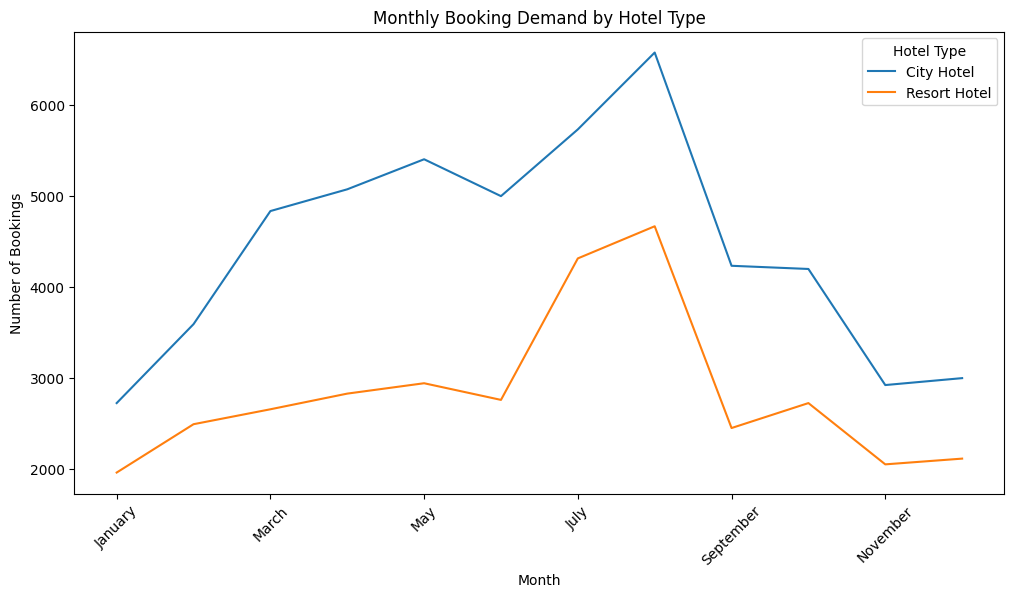

In [74]:
monthly_hotel.plot(x='month', y=['City Hotel', 'Resort Hotel'], kind='line', figsize=(12,6))

plt.title('Monthly Booking Demand by Hotel Type')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')

plt.show()

- City Hotels consistently receive more bookings than Resort Hotels throughout the year.
- Both hotel types experience peak demand during July and August.
- Booking demand declines after August for both hotel types.
- Resort Hotels show stronger seasonality, with a sharper increase during the summer months.

# **How are successful hotel bookings distributed across different countries worldwide?**

In [75]:
country_wise = hotel_df[hotel_df['is_canceled'] == 0]['country'].value_counts().reset_index()
country_wise.columns = ['country', 'bookings']
country_wise.head(10)

,country,bookings
0,PRT,17573
1,GBR,8440
2,FRA,7091
3,ESP,5382
4,DEU,4332
5,IRL,2347
6,ITA,1986
7,BEL,1670
8,NLD,1560
9,USA,1412


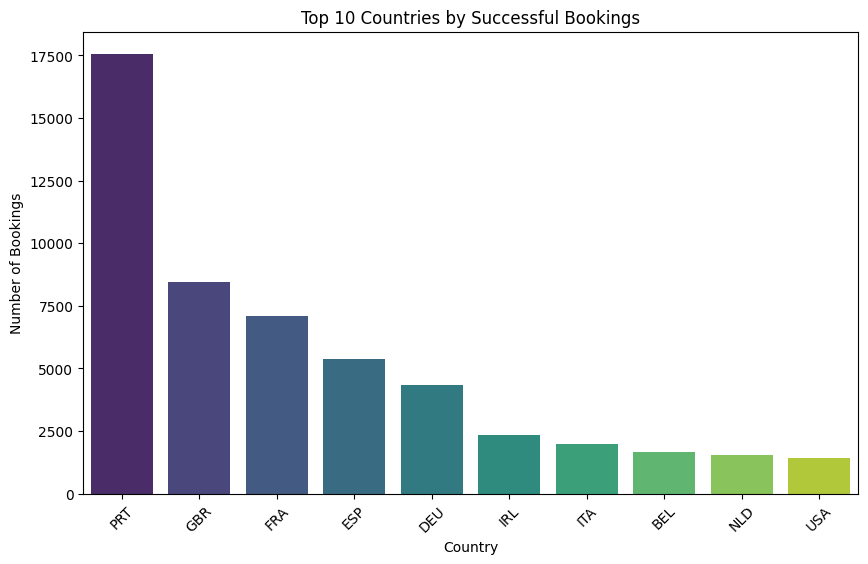

In [76]:
top_10 = country_wise.head(10)

plt.figure(figsize=(10,6))

sns.barplot(data=top_10, x='country', y='bookings', hue='country', palette='viridis', legend=False)

plt.title('Top 10 Countries by Successful Bookings')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)

plt.show()

- Portugal (PRT) contributes the highest number of successful hotel bookings, significantly outperforming all other countries.
- The United Kingdom (GBR), France (FRA), Spain (ESP), and Germany (DEU) are the next largest source markets.
- Most successful bookings come from European countries, indicating that the hotel's customer base is heavily concentrated in Europe.

In [34]:
fig = px.choropleth(country_wise, locations='country', color='bookings', hover_name='country', title='Successful Hotel Bookings by Country')
fig.show()

- Portugal (PRT) has the highest number of successful hotel bookings.
- The United Kingdom (GBR), France (FRA), and Spain (ESP) are also major contributors to hotel demand.
- Most successful bookings originate from European countries, indicating a strong concentration of demand from this region.

# **Which market segments contribute the most bookings for each hotel type?**

In [35]:
market_segment = pd.crosstab(hotel_df['market_segment'], hotel_df['hotel'])
market_segment

hotel,City Hotel,Resort Hotel
market_segment,,
Aviation,226,0
Complementary,503,189
Corporate,2218,1982
Direct,5538,6242
Groups,2619,2303
Offline TA/TO,7239,6616
Online TA,34929,16624


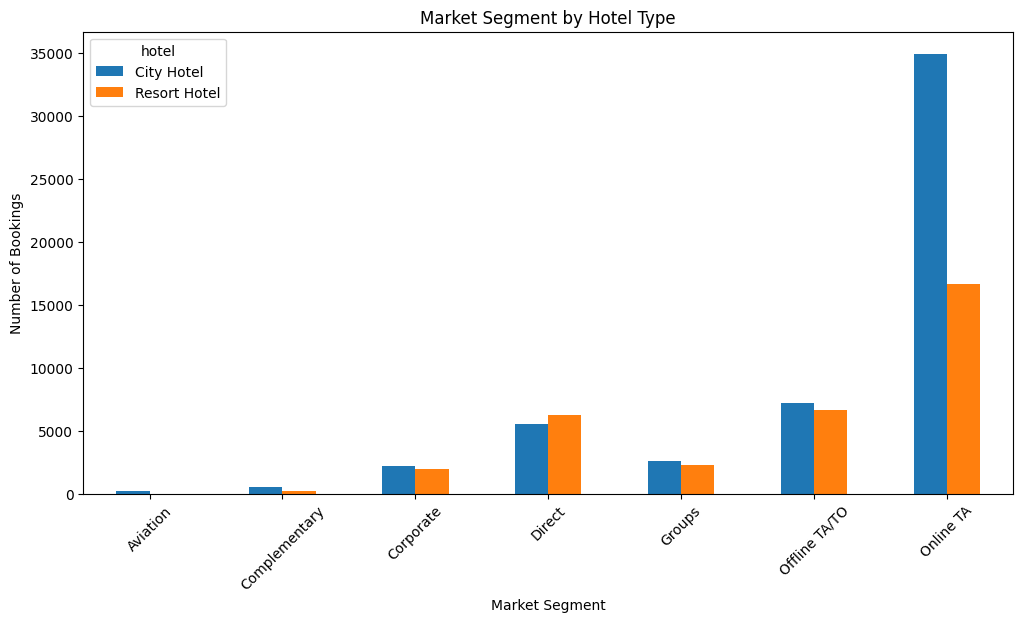

In [36]:
market_segment.plot(kind='bar', figsize=(12,6))

plt.title('Market Segment by Hotel Type')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)

plt.show()

- Online Travel Agencies (Online TA) generate the highest number of bookings for both City Hotels and Resort Hotels.
- City Hotels rely heavily on Online TA bookings compared to other market segments.
- Offline TA/TO and Direct bookings are the second-largest booking sources.
- Corporate, Groups, Aviation, and Complimentary segments contribute a relatively small share of total bookings.

# **How does the Average Daily Rate (ADR) vary across months for City Hotel and Resort Hotel?**

In [37]:
adr_data = hotel_df[hotel_df['is_canceled'] == 0]

resort_adr = adr_data[adr_data['hotel'] == 'Resort Hotel']
resort_adr = resort_adr.groupby('arrival_date_month')['adr'].mean().reset_index()

city_adr = adr_data[adr_data['hotel'] == 'City Hotel']
city_adr = city_adr.groupby('arrival_date_month')['adr'].mean().reset_index()

final_adr = resort_adr.merge(city_adr, on='arrival_date_month')
final_adr.columns = ['month', 'resort_adr', 'city_adr']
final_adr = final_adr.sort_values('month')

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

final_adr['month'] = pd.Categorical(final_adr['month'], categories=month_order, ordered=True)
final_adr = final_adr.sort_values('month').reset_index(drop=True)

In [38]:
final_adr

,month,resort_adr,city_adr
0,January,48.599615,83.378062
1,February,53.624311,88.210810
2,March,57.110018,91.306933
3,April,76.841664,114.251636
4,May,77.725129,124.825944
5,June,109.026942,120.673753
6,July,150.914540,120.069489
7,August,182.103524,122.825388
8,September,98.855456,116.973279
9,October,62.634853,105.517410


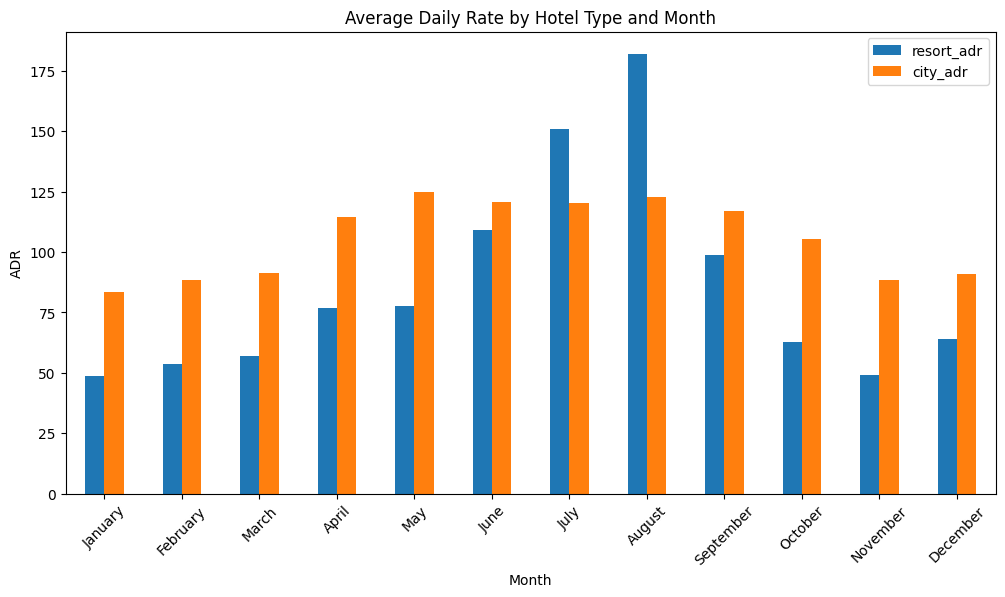

In [39]:
final_adr.plot(x='month', y=['resort_adr','city_adr'], kind='bar',figsize=(12,6))

plt.title('Average Daily Rate by Hotel Type and Month')
plt.xlabel('Month')
plt.ylabel('ADR')

plt.xticks(rotation=45)

plt.show()

- City Hotels maintain a relatively stable ADR throughout the year, generally ranging between 83 and 125.
- Resort Hotels show strong seasonal pricing patterns, with ADR increasing significantly during summer months.
- Resort Hotel ADR peaks in July and August, reaching its highest value in August (~182).
- During peak travel seasons, Resort Hotels charge substantially higher room rates than City Hotels.

# **Which deposit policies are associated with the highest booking cancellation rates?**

In [40]:
deposit_cancel = hotel_df.groupby('deposit_type')['is_canceled'].mean().reset_index()
deposit_cancel.columns = ['deposit_type', 'cancel_rate']
deposit_cancel

,deposit_type,cancel_rate
0,No Deposit,0.267161
1,Non Refund,0.947013
2,Refundable,0.242991


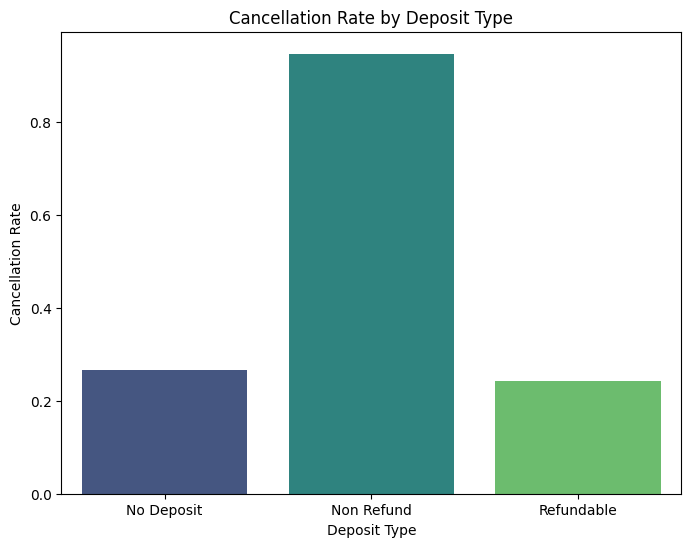

In [41]:
plt.figure(figsize=(8,6))

sns.barplot(data=deposit_cancel, x='deposit_type', y='cancel_rate', hue='deposit_type', palette='viridis', legend=False)

plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate')

plt.show()

- Non-Refund deposit bookings exhibit the highest cancellation rate (~95%), significantly higher than No Deposit and Refundable bookings.
- No Deposit and Refundable bookings show relatively similar cancellation rates (~24–27%).
- The relationship between deposit policy and cancellations appears highly uneven, suggesting customer behavior varies substantially across deposit types.

# **Which customer types have the highest cancellation rates?**

In [42]:
customer_cancel = hotel_df.groupby('customer_type')['is_canceled'].mean().reset_index()
customer_cancel.columns = ['customer_type','cancellations']

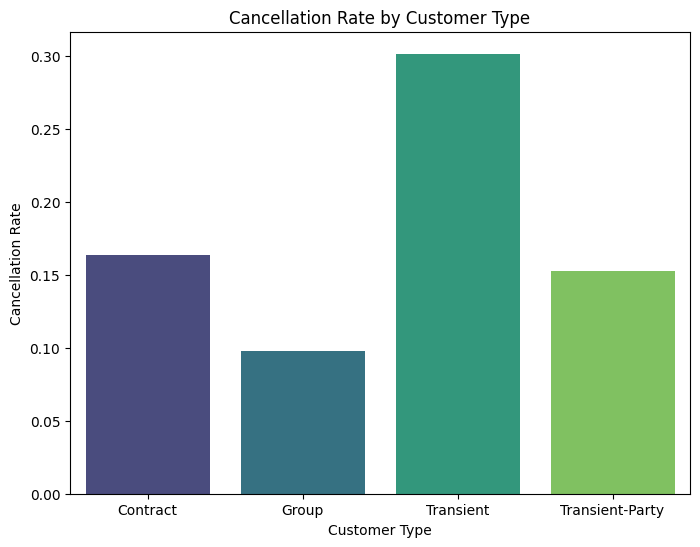

In [43]:
plt.figure(figsize=(8,6))

sns.barplot(data=customer_cancel, x='customer_type', y='cancellations', hue='customer_type', palette='viridis', legend=False)

plt.title('Cancellation Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate')

plt.show()

- Transient customers have the highest cancellation rate (30%), significantly higher than Contract (16%), Transient-Party (15%), and Group customers (10%).

- Transient customers also account for the largest share of hotel bookings.

- As a result, they contribute the most to overall booking cancellations, creating revenue uncertainty and occupancy fluctuations.

# **Conclusion**

The analysis reveals that City Hotels account for the majority of bookings and therefore represent the primary revenue source for the business. Booking demand increases significantly during the summer season, with July and August emerging as the busiest months.

1. City Hotels receive considerably more bookings than Resort Hotels, indicating stronger customer demand in urban locations.

2. Online Travel Agents (OTA) and Offline TA/TO channels generate the highest number of bookings, making them the most influential distribution channels.

3. Transient customers contribute the largest share of bookings but also exhibit the highest cancellation rate, making them a key segment for cancellation reduction strategies.

4. Non-Refund bookings show the highest cancellation rate among deposit policies, suggesting that deposit policies alone may not be sufficient to reduce cancellations.

5. ADR rises substantially during peak months, particularly for Resort Hotels, indicating opportunities for dynamic pricing and revenue optimization.
6. Successful bookings are heavily concentrated in Portugal, the United Kingdom, France, and Spain, highlighting these countries as important target markets.

7. Cancellation rates remain a significant challenge and can lead to revenue uncertainty, occupancy fluctuations, and inefficient resource planning.

8. Hotels should focus on strengthening high-performing booking channels, optimizing pricing during peak seasons, improving cancellation management, and targeting key customer markets to maximize revenue and occupancy.